# JAWAD HASSAN
# 2230-0035
# BS AI
# ML
# LAB 07
# Naive Bayes and Random Forest

In [ ]:
#libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.naive_bayes import MultinomialNB #good for dealing with words frequency
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score,mean_squared_error, mean_absolute_error, r2_score,precision_score,recall_score,f1_score,ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder,StandardScaler, OneHotEncoder,OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
import tensorflow as tf
from sklearn.datasets import load_iris,load_i



                                                text label
0  Go until jurong point, crazy.. Available only ...   ham
1                      Ok lar... Joking wif u oni...   ham
2  Free entry in 2 a wkly comp to win FA Cup fina...  spam
3  U dun say so early hor... U c already then say...   ham
4  Nah I don't think he goes to usf, he lives aro...   ham
accuracy_score: 0.9874439461883409
confusion_matrix:
 [[956  11]
 [  3 145]]
TP: 145
TN: 956
FP: 11
FN: 3


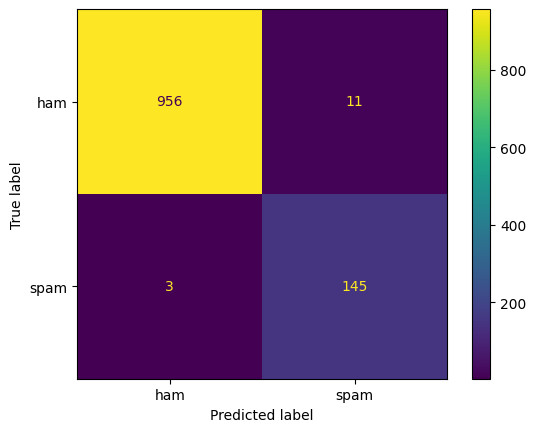

classsification_report:
               precision    recall  f1-score   support

         ham       1.00      0.99      0.99       967
        spam       0.93      0.98      0.95       148

    accuracy                           0.99      1115
   macro avg       0.96      0.98      0.97      1115
weighted avg       0.99      0.99      0.99      1115

Email Text: 'Hey, are we still meeting for lunch today? Let me know!'
Probability of being HAM (Normal): 1.0000 (100.00%)
Probability of being SPAM:         0.0000 (0.00%)

Email Text: 'WINNER!! You have been selected to receive a $1000 cash prize! Claim your reward by calling 09061701461 now!'
Probability of being HAM (Normal): 0.0000 (0.00%)
Probability of being SPAM:         1.0000 (100.00%)



In [37]:
#task1: Naïve Bayes’ Classifier on the SMS Spam
df=pd.read_csv("/Users/macbook/Desktop/sem6/ML/lab7/git7/sms_spam_dataset - sms_spam_dataset.csv",encoding='latin-1')
df=df[['v2','v1']]
df.columns=['text','label']
print(df.head())
vector=CountVectorizer()
x=vector.fit_transform(df['text'])
y=df['label']
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2)
#model train
nb=MultinomialNB()
nb.fit(xtrain,ytrain)
ypred=nb.predict(xtest)
print('accuracy_score:',accuracy_score(ytest,ypred))
cm=confusion_matrix(ytest,ypred)    
print('confusion_matrix:\n',cm)
tn, fp, fn, tp = cm.ravel()
print("TP:", tp)
print("TN:", tn)
print("FP:", fp)
print("FN:", fn)
ConfusionMatrixDisplay.from_predictions(ytest, ypred)
plt.show()
print('classsification_report:\n',classification_report(ytest,ypred))
#check with random samples:
def predict_email_probability(email_text):
    # Transform the incoming text using the same vectorizer
    email_vectorized = vector.transform([email_text])
    
    # predict_proba returns the probabilities for each class
    probabilities = nb.predict_proba(email_vectorized)[0]
    
    # nb_classifier.classes_ holds the label names (['ham', 'spam'])
    classes = nb.classes_
    
    # Extract specific probabilities by checking the class index
    ham_prob = probabilities[list(classes).index('ham')]
    spam_prob = probabilities[list(classes).index('spam')]
    
    # Print the results
    print(f"Email Text: '{email_text}'")
    print(f"Probability of being HAM (Normal): {ham_prob:.4f} ({ham_prob*100:.2f}%)")
    print(f"Probability of being SPAM:         {spam_prob:.4f} ({spam_prob*100:.2f}%)\n")

sample_normal = "Hey, are we still meeting for lunch today? Let me know!"
sample_spam = "WINNER!! You have been selected to receive a $1000 cash prize! Claim your reward by calling 09061701461 now!"

predict_email_probability(sample_normal)
predict_email_probability(sample_spam)

In [50]:
#task2: random forest classifier using car evaluation data
nam=['buying_price', 'maintenance_cost', 'number_of_doors', 
             'number_of_persons', 'lug_boot', 'safety', 'decision']
df=pd.read_csv("/Users/macbook/Desktop/sem6/ML/lab7/git7/car_evaluation.csv",header=None,names=nam)
print(df.head())
#preprocess
x=df.drop('decision',axis=1)
y=df['decision']
# Define the logical ranking for each column (Lowest to Highest)
buying_maint_order = ['low', 'med', 'high', 'vhigh']
doors_order        = ['2', '3', '4', '5more']
persons_order      = ['2', '4', 'more']
lug_boot_order     = ['small', 'med', 'big']
safety_order       = ['low', 'med', 'high']
encoder=OrdinalEncoder(categories=[
    buying_maint_order, 
    buying_maint_order, 
    doors_order,     
    persons_order,     
    lug_boot_order,    
    safety_order])
xencode=pd.DataFrame(encoder.fit_transform(x),columns=x.columns)
le=LabelEncoder()
yencode=le.fit_transform(y)
print(xencode.head())
#split
xtrain,xtest,ytrain,ytest=train_test_split(xencode,yencode,test_size=0.2,random_state=42)
rf=RandomForestClassifier(random_state=42)
rf.fit(xtrain,ytrain)
ypred=rf.predict(xtest)
print(f"\nRandom Forest Accuracy: {rf.score(xtest, ytest):.4f}")
#evaluation:
accuracy = accuracy_score(ytest, ypred)
print(f"Accuracy Score: {accuracy:.4f}")
print("\n--- Confusion Matrix ---")
conf_matrix = confusion_matrix(ytest, ypred)
print(conf_matrix)
print("\n--- Classification Report ---")
class_report = classification_report(ytest, ypred, target_names=le.classes_)
print(class_report)

  buying_price maintenance_cost number_of_doors number_of_persons lug_boot  \
0        vhigh            vhigh               2                 2    small   
1        vhigh            vhigh               2                 2    small   
2        vhigh            vhigh               2                 2    small   
3        vhigh            vhigh               2                 2      med   
4        vhigh            vhigh               2                 2      med   

  safety decision  
0    low    unacc  
1    med    unacc  
2   high    unacc  
3    low    unacc  
4    med    unacc  
   buying_price  maintenance_cost  number_of_doors  number_of_persons  \
0           3.0               3.0              0.0                0.0   
1           3.0               3.0              0.0                0.0   
2           3.0               3.0              0.0                0.0   
3           3.0               3.0              0.0                0.0   
4           3.0               3.0             

## Model Evaluation Interpretation:
### it is evaluated overall model accuracy is 96 percent, which is really good performance and model is highly reliable, now lets look at: 
### The confusion matrix shows us exactly where the model made mistakes:
### Row 1 (acc - Acceptable): Out of 83 cars, it got 74 right. It accidentally misclassified 6 as "good", 2 as "unacc", and 1 as "vgood".
### Row 2 (good): Out of 11 cars, it got 10 right. It misclassified 1 as "vgood".
### Row 3 (unacc - Unacceptable): Out of 235 cars, it got 235 right. It made zero mistakes here!
### Row 4 (vgood - Very Good): Out of 17 cars, it got 14 right. It misclassified 1 as "acc" and 2 as "good".
### Fortunately, the model learned exactly what makes a car "unacceptable" and catches them with 100% accuracy. The only slight confusion the model has is occasionally blurring the lines between acc, good, and vgood—which is completely natural since those are subjective, overlapping human concepts!

In [72]:
#activity pseudo classification
iris =load_iris()
x=iris.data
y=iris.target
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=42)
rf=RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(xtrain,ytrain)
ypred=rf.predict(xtest)
print('acc:',accuracy_score(ytest,ypred))
print(classification_report(ytest,ypred))


acc: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



mse 884.254589670399
mae 23.071349515599987
r2 0.9743018366825055


/var/folders/6x/gsds8kbx1ws82wz_r0cclt1m0000gn/T/ipykernel_43296/145040113.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  x_range = np.arange(min(xtest.values), max(xtest.values), 0.1).reshape(-1, 1)
/Users/macbook/Desktop/env/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


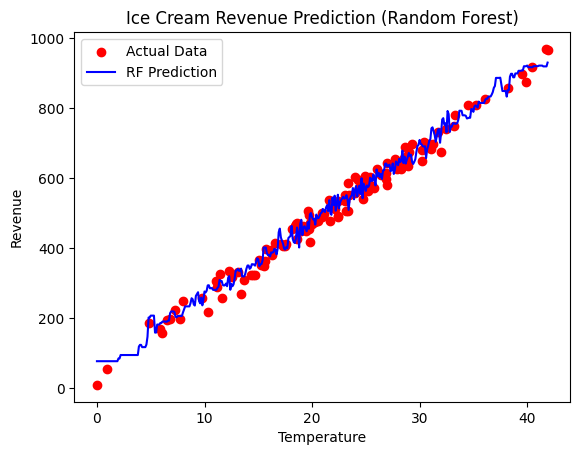

In [75]:
#activity pseudo regression
df=pd.read_csv("IceCreamData.csv")
x=df[['Temperature']]
y=df['Revenue']
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.25,random_state=0)
rf=RandomForestRegressor(n_estimators=10,random_state=0)
rf.fit(xtrain,ytrain)
ypred=rf.predict(xtest)
print('mse',mean_squared_error(ytest,ypred))
print('mae',mean_absolute_error(ytest,ypred))
print('r2',r2_score(ytest,ypred))
# Create a range of temperatures from min to max to see the 'steps'
x_range = np.arange(min(xtest.values), max(xtest.values), 0.1).reshape(-1, 1)
y_range_pred = rf.predict(x_range)

plt.scatter(xtest, ytest, color='red', label='Actual Data')
plt.plot(x_range, y_range_pred, color='blue', label='RF Prediction')
plt.title('Ice Cream Revenue Prediction (Random Forest)')
plt.xlabel('Temperature')
plt.ylabel('Revenue')
plt.legend()
plt.show()